# EDGES-3 Receiver Calibration

This memo notebook summarizes the results of careful matching of the EDGES-3 calibration with `edges-cal` to the output of Alan's C-code. 

The main result of this memo is that `edges-cal` **can now match the C-code to better than $10^{-7}$ precision** in the calibration parameters ($C_1$, $C_2$, $T_{\rm unc}$, $T_{\rm cos}$ and $T_{\rm sin}$). 



### C-Code Modifications

In [Memo #205](http://loco.lab.asu.edu/loco-memos/edges_reports/EDGES_Memo_205_v1.pdf) we described a small bug in `edges3.c` in which the `fittp()` function used one less channel than it should have when fitting S11's. 

## Python Code

`alancal` command is used (introduced and described in [Memo #205](http://loco.lab.asu.edu/loco-memos/edges_reports/EDGES_Memo_205_v1.pdf)), which uses `edges-cal` machinery to run calibration solutions as close as possible to the C-code. 

In this memo, we used the following command to produce the outputs:

```edges-cal alancal 2022_319_14 2022 316 -res 49.8 -ps 33 -cablen 4.26 -cabloss -91.5 -cabdiel -1.24 -fstart 48 -fstop 198 -smooth 8 -tload 300 -tcal 1000 -Lh -1 -wfstart 50.0 -wfstop 190.0 -tcold 306.5 -thot 393.22 -tcab 306.5 -cfit 7 -wfit 7 -nfit3 10 -nfit2 27 --redo-s11 --redo-cal --write-h5```


As can be seen, the input arguments to the CLI are, whenever possible, the same as the inputs to the C-code binaries. 

### Parameters

In [1]:
output_dir: str = "/data4/vydula/edges/packages/edges-bowman2018-pipeline/prefect-pipeline/output-notebooks/"
alan_dir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/alan_300_310_tests/"
data_dir: str = '/data5/edges/data/EDGES3_data/MRO/'


## The Comparisons

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from edges_cal.alanmode import read_spec_txt, read_specal
from click.testing import CliRunner
from edges_cal.cli import alancal
import traceback
import hickle


In [4]:
runner = CliRunner()

In [5]:
def read_s11m(pth):
    _s11m = np.genfromtxt(pth, comments="#", names=True)
    s11m = {}
    freq = _s11m["freq"]
    for name in _s11m.dtype.names:
        if name == "freq":
            continue

        bits = name.split("_")
        cmp = bits[-1]
        load = "_".join(bits[:-1])

        if load not in s11m:
            s11m[load] = np.zeros(len(_s11m), dtype=complex)
        if cmp == "real":
            s11m[load] += _s11m[name]
        else:
            s11m[load] += _s11m[name] * 1j

    return freq, pd.DataFrame(s11m)

In [6]:
output_dir = Path(output_dir)

## Run the Calibration

In [7]:

res = runner.invoke(
    alancal,
    [
        "2022_319_14",            # s11 date
        "2022",               # cal date
        "316",
        "--datadir", f"{data_dir}",
        "-res", "49.8",
        "-ps", "33",
        "-cablen", "4.26",
        "-cabloss", "-91.5",
        "-cabdiel", "-1.24",
        "-fstart", "48",
        "-fstop", "198",
        "-smooth", "8",
        "-tload", "300",
        "-tcal", "1000",
        "-Lh", "-1",
        "-wfstart", "50.0",
        "-wfstop", "190.0",
        "-tcold", "306.5",
        "-thot", "393.22",
        "-tcab", "306.5",
        "-cfit", "7",
        "-wfit", "7",
        "-nfit3", "10",
        "-nfit2", "27",
        "--redo-s11", 
        "--redo-cal",
        "--no-plot",
        "--out", str(output_dir),
        "--write-h5"
    ]
)

if res.exit_code:
    print(res.exception)
    print(traceback.print_exception(*res.exc_info))
    raise ValueError(res.exception)

Calibrating amb S11

Reading calibrated amb S11

Calibrating hot S11

Reading calibrated hot S11

Calibrating open S11

...

Using delay=0.02620000000000001 us for load short

BEST DELAY:  -4e-09

Saving modelled S11s

Saving hot-load loss model

Writing calibration results to 
/data4/vydula/edges/packages/edges-bowman2018-pipeline/prefect-pipeline/output-notebooks/specal.h5


### Check Modelling of S11's

In [19]:
loads = ['amb', 'hot', 'open', 'short']
_alans11m = np.genfromtxt(f"{alan_dir}/s11_modelled.txt", comments="#", names=True)
_ours11m = np.genfromtxt(f"{output_dir}/s11_modelled.txt", comments="#", names=True)


alans11m = {}
ours11m = {}
for load in loads + ['lna']:
    alans11m[load] = _alans11m[f"{load}_real"] + 1j*_alans11m[f"{load}_imag"]
    ours11m[load] = _ours11m[f"{load}_real"] + 1j*_ours11m[f"{load}_imag"]
    
assert np.allclose(_alans11m['freq'], _ours11m['freq'])

ValueError: operands could not be broadcast together with shapes (141,) (2868,) 

In [10]:
_alans11m['freq'], _ours11m['freq']

(array([ 48.00415 ,  48.052979,  48.101807, ..., 197.857666, 197.906494,
        197.955322]),
 array([ 50.006104,  50.054932,  50.10376 , ..., 189.898682, 189.94751 ,
        189.996338]))

In [ ]:
fig, ax = plt.subplots(len(alans11m), 1, sharex=True, constrained_layout=True, figsize=(8, 8))

for i, load in enumerate(alans11m):
    ax[i].plot(_alans11m['freq'], alans11m[load].real, label='alan real')
    ax[i].plot(_alans11m['freq'], ours11m[load].real, label='ea real')
    
    ax[i].plot(_alans11m['freq'], alans11m[load].imag, label='alan imag')
    ax[i].plot(_alans11m['freq'], ours11m[load].imag, label='ea imag')
    
    #ax[i].plot(alancal['freq'], np.abs(alans11m[load] - ours11m[load]), label='abs')
    ax[i].set_title(load)
    ax[i].grid()
ax[0].legend(ncols=3)

plt.suptitle('Modelled S11')

In [ ]:
fig, ax = plt.subplots(len(alans11m), 1, sharex=True, constrained_layout=True, figsize=(8,8))

for i, load in enumerate(alans11m):
    ax[i].plot(_alans11m['freq'], alans11m[load].real - ours11m[load].real, label='real')
    ax[i].plot(_alans11m['freq'], alans11m[load].imag - ours11m[load].imag, label='imag')
    ax[i].plot(_alans11m['freq'], np.abs(alans11m[load] - ours11m[load]), label='abs')
    ax[i].set_title(load)
    ax[i].grid()
ax[0].legend(ncols=3)

plt.suptitle('Difference in Modelled S11')
ax[4].set_xlabel('Frequency [MHz]')

**Figure 1 |** Comparison of smoothed/modelled $S_{11}$ values for all loads, including receiver and semi-rigid cable, between `edges-cal` and the C-code. The relative errors are generally less than one part in $10^8$. 

### Check Calibration Coefficients

In [11]:
ourcal = read_specal(f"{output_dir}/specal.txt")

In [12]:
alancal= read_specal(f"{alan_dir}/specal.txt")

Text(0.5, 0, 'Frequency [MHz]')

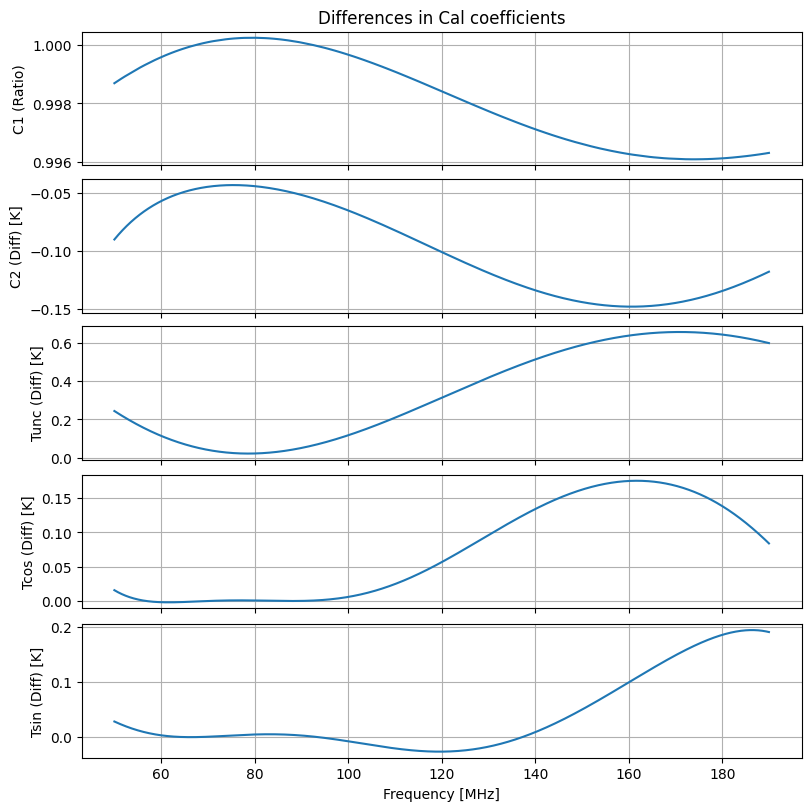

In [13]:
fig, ax = plt.subplots(len(alancal.dtype.names)-4, 1, sharex=True, constrained_layout=True, figsize=(8, 8))

j = 0
for i, name in enumerate(alancal.dtype.names):
    if name in ('freq', 'weight', 's11lna_real', 's11lna_imag'):
        continue
    if name=='C1':
        ax[j].plot(alancal['freq'], alancal[name] / ourcal[name])
        ax[j].set_ylabel(name + ' (Ratio)')
    else:
        ax[j].plot(alancal['freq'], alancal[name] - ourcal[name])
        ax[j].set_ylabel(name + ' (Diff) [K]')
    ax[j].grid()
    
    j += 1
    
ax[0].set_title('Differences in Cal coefficients')
ax[4].set_xlabel('Frequency [MHz]')

**Figure 2 |** Absolute differences between calibration coefficients and LNA $S_{11}$, as saved in the `specal.txt` file from the `edges3.c` pipeline. 

In [16]:
ourcal, alancal

(array([( 50.006104, 0.006173, 0.007455, 1.320415, -6.688456, 194.977605, -13.978894, -10.546868, 1.),
        ( 50.054932, 0.006197, 0.007422, 1.320244, -6.688381, 194.962607, -13.902443, -10.504768, 1.),
        ( 50.10376 , 0.006221, 0.007388, 1.320072, -6.688308, 194.947628, -13.826269, -10.462617, 1.),
        ...,
        (189.898682, 0.007444, 0.041872, 1.031472, -6.914954, 184.067584, -31.00942 , -27.566093, 1.),
        (189.94751 , 0.007486, 0.041885, 1.031416, -6.915372, 184.065801, -30.98596 , -27.585429, 1.),
        (189.996338, 0.007529, 0.041898, 1.03136 , -6.91579 , 184.064008, -30.962479, -27.604675, 1.)],
       dtype=[('freq', '<f8'), ('s11lna_real', '<f8'), ('s11lna_imag', '<f8'), ('C1', '<f8'), ('C2', '<f8'), ('Tunc', '<f8'), ('Tcos', '<f8'), ('Tsin', '<f8'), ('weight', '<f8')]),
 array([( 50.006104, 0.00622075, 0.00751698, 1.31868014, -6.77843113, 195.22187631, -13.96335771, -10.51890706, 1.),
        ( 50.054932, 0.00624385, 0.00748141, 1.31851586, -6.77811449, 